# The Fourth Circle: Neural Networks, Part Three 
## Recurrent Neural Networks II: Long Short-Term Memory and Gated Recurrent Unit

<br/>
Jiří Fejlek

2026-03-19
<br/>

## Table of Contents

- [Long Short-Term Memory](#lstm)
    - [Implementation](#impl_lstm)
    - [Training LSTM on The Time Machine](#train_lstm)
- [Gated Recurrent Unit](#gru)
    - [Implementation](#impl_gru)
    - [Training GRU on The Time Machine](#train_gru)
- [Copy Memory Task](#copy)
- [References](#references)

In the second part of our introduction to RNN architectures, we will describe the Long Short-Term Memory (LSTM) RNN model [[1](#1)] from 1997 and Gated Recurrent Unit (GRU) [[2](#2)] from 2014. In the previous part, we described a simple RNN (the Elman network). A prominent issue with simple RNNs is the vanishing gradient problem, which occurs more frequently in RNN designs due to *backpropagation through time* (i.e., the sequential step-by-step evaluation of the input sequence, which is a cornerstone of RNNs). LSTM and GRU networks aim to alleviate the vanishing gradient problem by building more sophisticated memory models.

First, we will review several functions we implemented in Recurrent Neural Networks I and use in this presentation.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 3050 Laptop GPU'

In [3]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [4]:
class TimeMachine: 
    
    def _read(self): # read the text 
        return open('C:/Users/elini/Desktop/nine circles 2/timemachine.txt').read()
        
    def _preprocess(self, text): # replace special characters with ' ', convert upper cases to lower case
        return re.sub('[^A-Za-z]+', ' ', open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()).lower()

    def _tokenize(self, text): # convert text to a list of words
         return text.split()
        
    def _build(self, raw_text, vocab=None): # build vocabulary
        tokens = self._tokenize(self._preprocess(raw_text))
        if vocab is None: 
            vocab = Vocabulary(tokens)
        corpus = [vocab[token] for token in tokens]
        return corpus, vocab
        
    ################################
    
    def __init__(self, batch_size, num_steps, num_train = 10000, num_test = 5000):  

        self.batch_size = batch_size
        self.num_train = num_train
        self.num_test = num_test
        
        corpus, self.vocab = self._build(self._read()) # build vocabulary
        array = torch.tensor([corpus[i:i+num_steps+1] for i in range(len(corpus)-num_steps)]) # extract sequences from the text
        self.X, self.Y = array[:,:-1], array[:,1:] # Y is shifted by one index

    
    # dataloader
    def get_dataloader(self, train): 
        # sequences till num_train are from the train set, the latter are from the test set 
        idx = slice(0, self.num_train) if train else slice(self.num_train, self.num_train + self.num_test) 
        return self.get_tensorloader([self.X, self.Y], train, idx)
        
    def train_dataloader(self):
        return self.get_dataloader(train=True)
        
    def test_dataloader(self):
        return self.get_dataloader(train=False)
        
    # we will simply use the dataloader from torch
    def get_tensorloader(self, tensors, train, indices=slice(0, None)):
        tensors = tuple(a[indices] for a in tensors) # get train/test sequences based on idx
        dataset = torch.utils.data.TensorDataset(*tensors) 
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)    

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits, state = model(X) # forward pass
        
        loss = loss_fn(pred_logits.permute(1, 2, 0), y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
           
    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            state = None
            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test, state = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test.permute(1, 2, 0), y_test)*len(X_test)
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

In [6]:
def predict(model, prefix, num_preds, vocab, device):
    prefix = prefix.split()
    prefix = torch.tensor([vocab.__getitem__(prefix)]).to(cuda_device)
    state = None

    for i in range(num_preds):
        Y_pred, state = model(prefix, state)
        Y_pred = Y_pred[-1,::]
        prefix = torch.cat((prefix[0],Y_pred.argmax()[None]),0)[None,:]

    predicted_text = vocab.to_tokens(prefix[0].tolist())
    delimeter = ' '
        
    return delimeter.join(predicted_text)

## Long Short-Term Memory <a class="anchor" id="lstm"></a>

An LSTM neural network is made of so-called *memory cells*. Each memory cell contains an additional *internal state* $c_t$ that helps to ensure that the gradient can pass across many time steps without vanishing or exploding [[3](#3)]. A memory cell also consists of several *memory gates*: i_t

- *input gate* $i_t$
- *output gate* $o_t$
- *forget gate* $f_t$

which are computed for the $t$th element of the input sequence $x_t$ and for the hidden state $h_t$ as follows
$$ i_t = \sigma  (W_{xi}x_t + W_{hi}H_{t-1} + b_i), $$
$$ o_t = \sigma  (W_{xo}x_t + W_{ho}H_{t-1} + b_o), $$
$$ f_t = \sigma  (W_{xf}x_t + W_{hf}H_{t-1} + b_f), $$
where  $W_{hi}, W_{hf}, W_{ho}$ are matrices of weights and $b_i, b_f$ and $b_o$ are bias vectors.

The input gate modifies the current memory cell internal state $c_t$. The output gate determines the memory cell's influence on the output at the current time step. The forget gate determines whether to keep the current value of $c_t$ or to forget it. The hidden state $h_t$ and the internal state $c_t$ are updated as follows
$$ h_t = o_t \odot \text{tanh } c_t $$
and
$$ c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_{t-1},$$
where $\odot$ is the Hadamard (elementwise) product and $\tilde{c}_{t-1}$ is a so called inner node and is computed as
$$ \tilde{c}_t = \text{tanh }(W_{xc}x_t + W_{xh}h_{t-1} + b_c)$$
for some weights $W_{xc}$ and a bias term $b_c$.


Overall, we get the following architecture of the memory cell [[3](#3)].

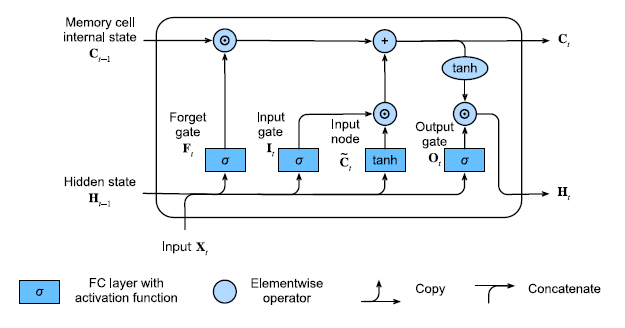

### Implementation <a class="anchor" id="impl_lstm"></a>

Let us implement the LSTM recurrent neural network. The implementation is again quite straightforward since the LSTM memory cell is already implemented in PyTorch. Our code is very similar to our simple RNN *RNN_Model*. We just need to replace the recurrent layer *nn.RNN* with the recurrent layer *nn.LSTM*. In addition, we need to keep in mind that *nn.LSTM* has an inner state in addition to the hidden state, and change the code accordingly. 

In [7]:
class LSTM_Model(nn.Module):

    def __init__(self, num_hiddens, num_layers, vocab_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        
        self.rnn = nn.LSTM(vocab_size, num_hiddens, num_layers)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, inputs, hc_state = None):

        
        if hc_state is None:
            h_state = torch.zeros((self.num_layers, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial hidden state: num_layers x batch_size x num_hiddens
            c_state = torch.zeros((self.num_layers, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial cell internal state: num_layers x batch_size x num_hiddens
        else:
            h_state, c_state = hc_state
             
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32) # one-hot encode input 
        Y, (h_state, c_state) = self.rnn(X, (h_state, c_state))

        output = self.linear(Y)
        return output, (h_state, c_state)

### Training LSTM on The Time Machine <a class="anchor" id="train_lstm"></a> 

Let us train our LSTM RNN model on the text of The Time Machine.

In [8]:
torch.manual_seed(123)

# data loader
TimeMachine_data = TimeMachine(batch_size= 1000, num_steps = 10, num_train = 25000, num_test = 5000)
TimeMachine_train_loader = TimeMachine_data.train_dataloader()
TimeMachine_test_loader = TimeMachine_data.test_dataloader()


# googlenet initialization
LSTM_Model_cuda = LSTM_Model(num_hiddens = 64, num_layers = 1, vocab_size = TimeMachine_data.vocab.__len__()).to(cuda_device)


optim_SGD_cuda =  torch.optim.SGD(LSTM_Model_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100, 125], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(TimeMachine_train_loader, TimeMachine_test_loader, LSTM_Model_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

194.73570919036865


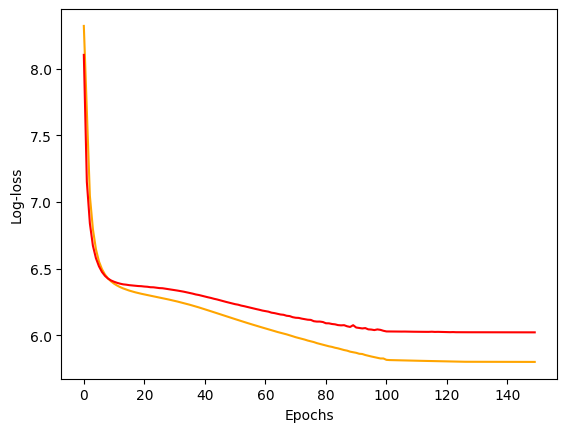

In [9]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

We can again look at the predictions of our models.

In [10]:
predict(LSTM_Model_cuda, 'it was', 20, TimeMachine_data.vocab, cuda_device)

'it was a little man of the time traveller was a time and i had a little time and i had a'

In [11]:
predict(LSTM_Model_cuda, 'i am', 20, TimeMachine_data.vocab, cuda_device)

'i am to a time and i had a little time and i had a little time and i had a little'

In [12]:
predict(LSTM_Model_cuda, 'it is not a sword', 20, TimeMachine_data.vocab, cuda_device)

'it is not a sword of the time traveller was a time and i had a little time and i had a little time and'

## Gated Recurrent Unit <a class="anchor" id="gru"></a>

Gated Recurrent Unit (GRU) [[2](#2)] is a simplified version of the Long Short-Term Memory (LSTM) memory cell architecture. It offers a more streamlined, easier-to-compute memory unit that retains the advantages of LSTMs. The architecture of the GRU is as follows [[3](#3)].

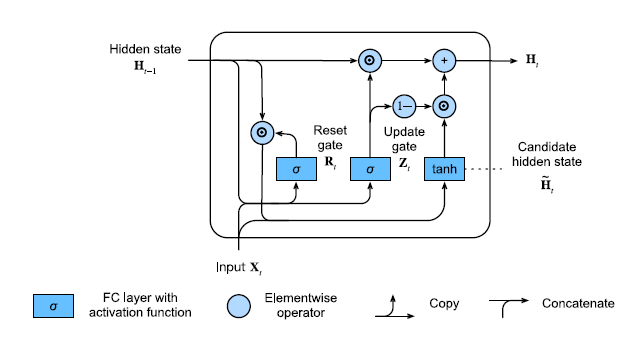

Unlike an LSTM memory cell, a GRU unit consists of only two gates: a reset gate and an update gate [[3](#3)]:
$$ r_t = \sigma  (W_{xr}x_t + W_{hr}h_{t-1} + b_r), $$
$$ z_t = \sigma  (W_{xz}x_t + W_{hz}h_{t-1} + b_z), $$
where $W_{xr}, W_{xz}$ are weight matrices and $b_r, b_z$ are biases. The hidden state of the RNN is updated as follows
$$ h_t = z_t \odot h_{t-1} + (1-z_t) \odot \tilde{h}_t,$$
where $\tilde{h}_t$ is a *candidate hidden state*
$$ \tilde{h}_t = \text{tanh } \left(  W_{xh} x_t + W_{hh}(r_t \odot h_{t-1}) + b_h \right)$$
where  $W_{xh}, W_{hh}$ are weight matrices and $b_h$ is a bias term. 

From these equations, we observe that the update gate determines whether we update the hidden state or retain the existing one. On the other hand, the reset gate can "reset" the memorized hidden state and create a new candidate purely from the current input. 

### Implementation <a class="anchor" id="impl_gru"></a>

Next, let us implement the GRU recurrent neural network. Similarly to the LSTM memory cell, the GRU is implemented in PyTorch as *nn.GRU*. Since the GRU architecture does not contain any additional inner state,  we can simply reuse our implementation of the simple RNN and replace *nn.RNN* with *nn.GRU*.

In [13]:
class GRU_Model(nn.Module):

    def __init__(self, num_hiddens, num_layers, vocab_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        
        self.rnn = nn.GRU(vocab_size, num_hiddens, num_layers)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros((self.num_layers, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial hidden state: num_layers x batch_size x num_hiddens
            
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32) # one-hot encode input 
        Y, state = self.rnn(X, state)

        output = self.linear(Y)
        return output, state

### Training GRU on The Time Machine <a class="anchor" id="train_gru"></a> 

Now, we can train our GRU RNN model.

In [14]:
torch.manual_seed(123)

# data loader
TimeMachine_data = TimeMachine(batch_size= 1000, num_steps = 10, num_train = 25000, num_test = 5000)
TimeMachine_train_loader = TimeMachine_data.train_dataloader()
TimeMachine_test_loader = TimeMachine_data.test_dataloader()


# googlenet initialization
GRU_Model_cuda = GRU_Model(num_hiddens = 64, num_layers = 1, vocab_size = TimeMachine_data.vocab.__len__()).to(cuda_device)


optim_SGD_cuda =  torch.optim.SGD(GRU_Model_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100, 125], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(TimeMachine_train_loader, TimeMachine_test_loader, GRU_Model_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

190.98162531852722


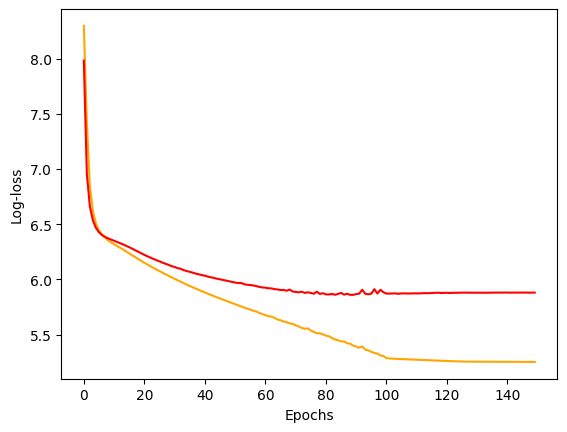

In [15]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [16]:
predict(GRU_Model_cuda, 'it was', 20, TimeMachine_data.vocab, cuda_device)

'it was a little man i had a little man i had a little man i had a little man i had'

In [17]:
predict(GRU_Model_cuda, 'i am', 20, TimeMachine_data.vocab, cuda_device)

'i am not a little man i had a little man i had a little man i had a little man i'

In [18]:
predict(GRU_Model_cuda, 'it is not a sword', 20, TimeMachine_data.vocab, cuda_device)

'it is not a sword i was not a little man i had a little man i had a little man i had a little'

## Copy Memory Task <a class="anchor" id="copy"></a>

As the final part of this project, let us test all the RNN architectures (simple RNN, LSTM, and GRU) we introduced so far on a task that allows us to more easily compare the results. Namely, we will consider the copy memory task that is illustrated, for example, in [[4](#4)].  The input sequences consist of a sequence of numbers (e.g., 1-9), followed by a fixed number of zeros. The sequence that consists of a special character (we will use 10) followed by more zeros. The special character denotes a place where the original sequence should be *copied*, i.e., the corresponding correct output should be the sequence of zeros followed by the original non-zero sequence. The goal is to test the neural network's ability to remember the sequence's beginning even after some time steps have passed.

The input and output sequences are probably best understood from the example. 

In [19]:
def generate_copy_dataset(n_data, len_sequence, len_wait):
    
    seq = np.random.randint(low = 1, high = 10, size= (n_data, len_sequence))
    
    zeros1 = np.zeros((n_data, len_wait-1))
    zeros2 = np.zeros((n_data, len_wait))
    zeros3 = np.zeros((n_data, len_sequence))

    marker = 10 * np.ones((n_data, 1))
    
    x = torch.tensor(np.concatenate((seq, zeros1, marker, zeros3), axis=1), dtype=torch.long)
    y = torch.tensor(np.concatenate((zeros3, zeros2, seq), axis=1), dtype = torch.long)

    return x, y

In [20]:
len_wait = 15 # length of zeros
len_sequence = 5 # length of non-zero sequence

x,y = generate_copy_dataset(1, len_sequence, len_wait)
print(x)
print(y)

tensor([[ 1,  3,  4,  3,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0, 10,  0,  0,  0,  0,  0]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 4, 3,
         3]])


Let us implement a dataset of 50000 training sequences and 5000 test sequences.

In [21]:
X_train, Y_train = generate_copy_dataset(50000, len_sequence, len_wait)
X_test, Y_test = generate_copy_dataset(5000, len_sequence, len_wait)

train_copy_dataset = torch.utils.data.TensorDataset(*(X_train, Y_train)) 
test_copy_dataset = torch.utils.data.TensorDataset(*(X_test, Y_test)) 

train_copy_dataloader = torch.utils.data.DataLoader(train_copy_dataset, batch_size = 1000, shuffle=True) 
test_copy_dataloader = torch.utils.data.DataLoader(test_copy_dataset, batch_size = 1000, shuffle=False) 

In [22]:
for X, Y in train_copy_dataloader:
    print('X:', X, '\nY:', Y)
    break

X: tensor([[7, 8, 4,  ..., 0, 0, 0],
        [3, 5, 9,  ..., 0, 0, 0],
        [8, 3, 2,  ..., 0, 0, 0],
        ...,
        [9, 2, 1,  ..., 0, 0, 0],
        [4, 3, 2,  ..., 0, 0, 0],
        [2, 4, 3,  ..., 0, 0, 0]]) 
Y: tensor([[0, 0, 0,  ..., 4, 7, 2],
        [0, 0, 0,  ..., 9, 6, 5],
        [0, 0, 0,  ..., 2, 4, 7],
        ...,
        [0, 0, 0,  ..., 1, 4, 4],
        [0, 0, 0,  ..., 2, 1, 3],
        [0, 0, 0,  ..., 3, 7, 3]])


We will first train a simple RNN (the Elman network).

In [23]:
class RNN_Model(nn.Module):

    def __init__(self, num_hiddens, num_layers, vocab_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        
        self.rnn = nn.RNN(vocab_size, num_hiddens, num_layers)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros((self.num_layers, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial hidden state: num_layers x batch_size x num_hiddens
            
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32) # one-hot encode input 
        Y, state = self.rnn(X, state)

        output = self.linear(Y)
        return output, state

In [24]:
torch.manual_seed(123)
RNN_Model_cuda = RNN_Model(num_hiddens = 50, num_layers = 1, vocab_size = 12).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(RNN_Model_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[1000], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 1

n_epochs = 1000

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(train_copy_dataloader, test_copy_dataloader, RNN_Model_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

776.8758473396301


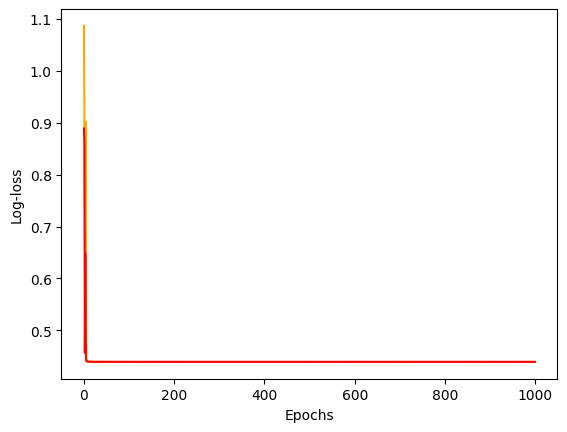

In [25]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [26]:
loss_epochs_test.min()

0.43943285942077637

We obtained a non-zero log loss, indicating that our model did not fully remember the initial sequence. 

In [27]:
x = (test_copy_dataset.__getitem__(1)[0]).to(cuda_device)
x = x[None,:]
x

tensor([[ 5,  9,  1,  1,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0, 10,  0,  0,  0,  0,  0]], device='cuda:0')

In [28]:
RNN_Model_cuda(x)[0].argmax(2).flatten()

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 4, 4, 1,
        8], device='cuda:0')

Let us evaluate the overall accuracy on the test set. 

In [29]:
accu_sum = 0
for X, Y in test_copy_dataloader:
    accu_sum = accu_sum + ((RNN_Model_cuda(X.to(cuda_device))[0].argmax(2).permute(1,0) - Y.to(cuda_device)).abs() == 0).long().sum()/25/1000
accu = accu_sum/5   
accu

tensor(0.8225, device='cuda:0')

The accuracy is over 80%. However, we need to remember that the first 20 characters, which are always zero (i.e., 80% accuracy), are "free". To better illustrate how good the result is, let us compare the accuracy of our simple RNN with the accuracy of uniform random guessing. 

In [30]:
accu_sum = 0
for X, Y in test_copy_dataloader:

    x,Y_rand = generate_copy_dataset(1000, len_sequence, len_wait)
    accu_sum = accu_sum + ((Y_rand.to(cuda_device) - Y.to(cuda_device)).abs() == 0).long().sum()/25/1000
    
accu = accu_sum/5   
accu

tensor(0.8224, device='cuda:0')

The simple RNN did not improve the naive prediction. Let us see whether the LSTM architecture does better.

In [31]:
torch.manual_seed(123)
LSTM_Model_cuda = LSTM_Model(num_hiddens = 50, num_layers = 1, vocab_size = 12).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(LSTM_Model_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[1000], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 1

n_epochs = 1000

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(train_copy_dataloader, test_copy_dataloader, LSTM_Model_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

874.0082910060883


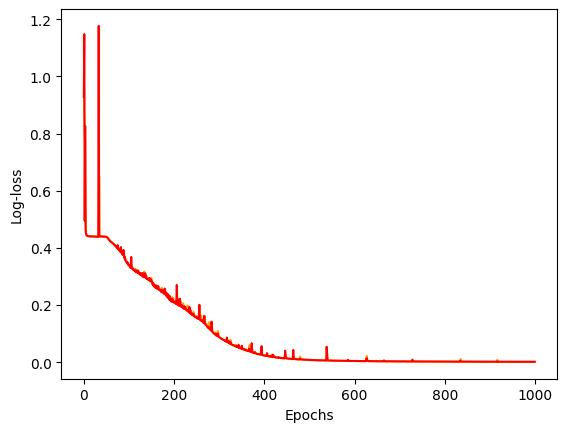

In [32]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [33]:
loss_epochs_test.min()

0.0011703114723786712

We observe that the LSTM model remembered the sequences well.

In [34]:
x = (test_copy_dataset.__getitem__(1)[0]).to(cuda_device)
x = x[None,:]
x

tensor([[ 5,  9,  1,  1,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0, 10,  0,  0,  0,  0,  0]], device='cuda:0')

In [35]:
LSTM_Model_cuda(x)[0].argmax(2).flatten()

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 9, 1, 1,
        5], device='cuda:0')

In [36]:
accu_sum = 0
for X, Y in test_copy_dataloader:
    accu_sum = accu_sum + ((LSTM_Model_cuda(X.to(cuda_device))[0].argmax(2).permute(1,0) - Y.to(cuda_device)).abs() == 0).long().sum()/25/1000
accu = accu_sum/5   
accu

tensor(0.9998, device='cuda:0')

We will also train the GRU model.

In [37]:
torch.manual_seed(123)
GRU_Model_cuda = GRU_Model(num_hiddens = 50, num_layers = 1, vocab_size = 12).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(GRU_Model_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[1000], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 1

n_epochs = 1000

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(train_copy_dataloader, test_copy_dataloader, GRU_Model_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

904.126275062561


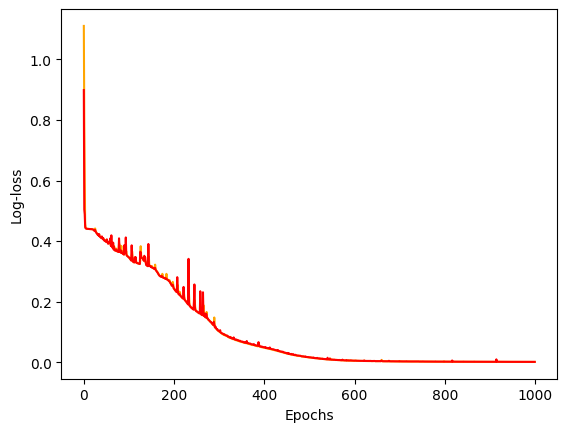

In [38]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [39]:
loss_epochs_test.min()

0.0008845336851663888

In [40]:
x = (test_copy_dataset.__getitem__(1)[0]).to(cuda_device)
x = x[None,:]
x

tensor([[ 5,  9,  1,  1,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0, 10,  0,  0,  0,  0,  0]], device='cuda:0')

In [41]:
GRU_Model_cuda(x)[0].argmax(2).flatten()

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 9, 1, 1,
        5], device='cuda:0')

In [42]:
accu_sum = 0
for X, Y in test_copy_dataloader:
    accu_sum = accu_sum + ((GRU_Model_cuda(X.to(cuda_device))[0].argmax(2).permute(1,0) - Y.to(cuda_device)).abs() == 0).long().sum()/25/1000
accu = accu_sum/5   
accu

tensor(1.0000, device='cuda:0')

The GRU model also successfully performed the copying task.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> HOCHREITER, Sepp; SCHMIDHUBER, Jürgen. Long short-term memory. *Neural computation*, 1997, 9.8: 1735-1780.

<a id="2">[2]</a> CHO, Kyunghyun, et al. Learning phrase representations using RNN encoder–decoder for statistical machine translation. In: *Proceedings of the 2014 conference on empirical methods in natural language processing (EMNLP).* 2014. p. 1724-1734.

<a id="3">[3]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="4">[4]</a> ARJOVSKY, Martin; SHAH, Amar; BENGIO, Yoshua. Unitary evolution recurrent neural networks. In: *International conference on machine learning.* PMLR, 2016. p. 1120-1128.